In [12]:
import os
import ee
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import io
import json
from shapely.geometry import Polygon, box, LineString, Point
from shapely.affinity import rotate
import matplotlib.pyplot as plt
from math import pi
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize
import cv2
from scipy.spatial import ConvexHull
from tqdm.notebook import tqdm
import contextily as ctx
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, Normalize
from shapely.ops import unary_union
import time

### Area of interest acquisition

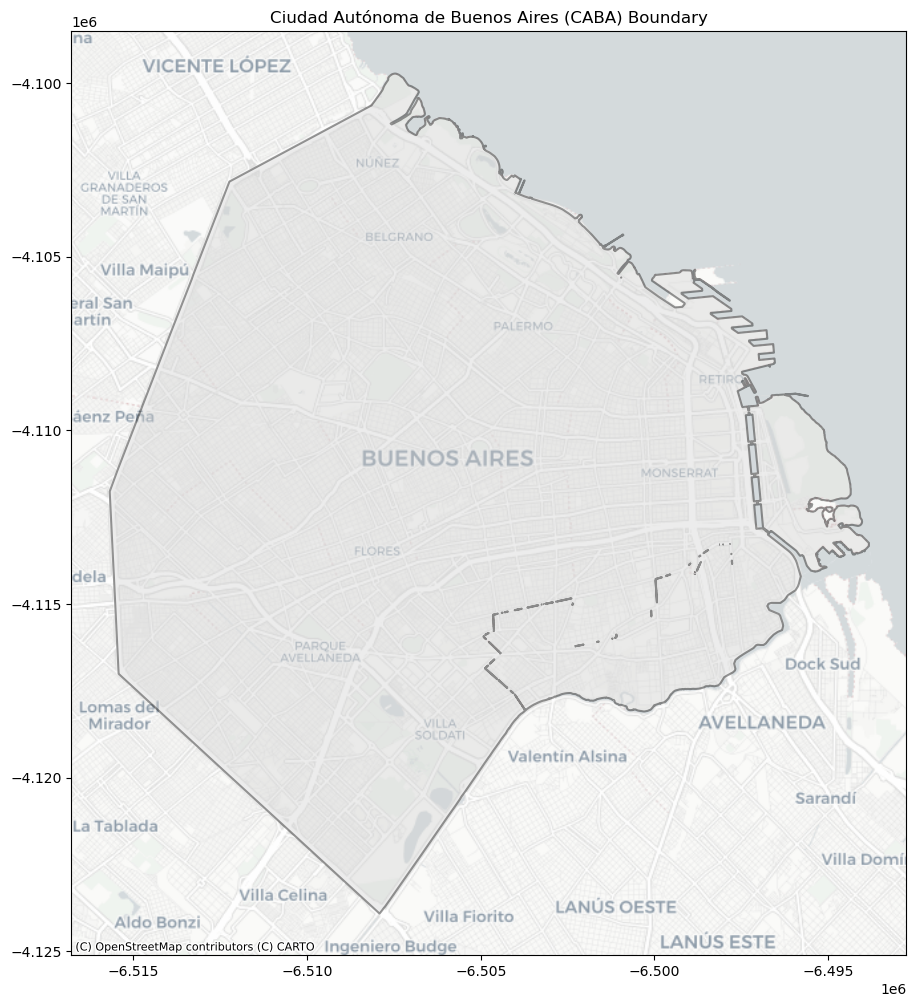

In [13]:

def download_caba_boundary(output_path="caba_boundary.geojson"):

    # Official open data portal of the city of Buenos Aires
    url = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson"

    try:
        # Join the different geometries into a single one. The dataset is divided by boroughs
        gdf = gpd.read_file(url)
        unified_boundary = gdf.unary_union
        caba_gdf = gpd.GeoDataFrame(
            {'name': ['CABA']},
            geometry=[unified_boundary],
            crs=gdf.crs
        )
        return caba_gdf
    except Exception as e:
        print(f"Error: {e}")
        return None
boundary = download_caba_boundary()


# Plot to check everything
fig, ax = plt.subplots(figsize=(12, 12))
boundary = boundary.to_crs(epsg=3857)
boundary.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=1.5, alpha=0.4)
# Add basemap for context
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
plt.title('Ciudad Autónoma de Buenos Aires (CABA) Boundary');

In [14]:
## For an alternative AOI load your specficic data into a geodataframe called boundary
#boundary = gpd.read_file("path_to_your_boundary_file.geojson")

### Downloading buildings dataset for AOI

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import ee
import json

# Initialize Earth Engine
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()

def extract_buildings(boundary):
    """Func to extract all buildiings vectors using Google's Open Buildings dataset.
    """
    
    # Earth Engine requires WGS84 coordinates
    boundary_wgs84 = boundary.to_crs(epsg=4326)

    # Convert boundary to Earth Engine format
    boundary_json = json.loads(boundary_wgs84.to_json())
    feature = boundary_json['features'][0]

    # Create appropriate geometry type
    if feature['geometry']['type'] == 'Polygon':
        ee_boundary = ee.Geometry.Polygon(feature['geometry']['coordinates'])
    else:  # MultiPolygon
        ee_boundary = ee.Geometry.MultiPolygon(feature['geometry']['coordinates'])

    # Get building dataset and filter
    buildings = ee.FeatureCollection('GOOGLE/Research/open-buildings/v3/polygons')
    caba_buildings = buildings.filterBounds(ee_boundary)

    filtered_buildings = caba_buildings

    # Start export task to Google Drive
    task = ee.batch.Export.table.toDrive(
        collection=filtered_buildings,
        description='CABA_Buildings',
        folder='Urban_Morphology',
        fileFormat='GeoJSON'
    )

    task.start()
    return task

task = extract_buildings(boundary)
print(f"Task ID: {task.id}")

Task ID: RIY7UOF7NBWO2OVYR4DVSRC2


In [16]:
# After the task completes, download the GeoJSON file from Google Drive folder 'Urban_Morphology', 
# and provide the path to the downloaded file in the next cell.

In [17]:
# Path to the downloaded buildings dataset
buildings_path = "/Users/santi/DataspellProjects/Techo/Data/CABA_Buildings.geojson"
buildings_caba = gpd.read_file(buildings_path)
buildings_caba.head(10)

,id,area_in_meters,confidence,full_plus_code,longitude_latitude,geometry
0,121f0000000000033040,50.106400,0.6875,48Q39J8P+MWGC,"{'type': 'Point', 'coordinates': [-58.36268105...","POLYGON ((-58.36262 -34.63332, -58.36265 -34.6..."
1,121f0000000000058f01,22.878099,0.6875,48Q39JJH+GQXF,"{'type': 'Point', 'coordinates': [-58.37052015...","POLYGON ((-58.37049 -34.61866, -58.37049 -34.6..."
2,121f00000000000986fb,70.144302,0.6875,48Q39J6M+V8HF,"{'type': 'Point', 'coordinates': [-58.36664073...","POLYGON ((-58.36660 -34.63785, -58.36661 -34.6..."
3,121f00000000000c9fa2,15.666800,0.6875,48Q39JCM+WCMQ,"{'type': 'Point', 'coordinates': [-58.36644453...","POLYGON ((-58.36641 -34.62766, -58.36645 -34.6..."
4,121f00000000000e1796,40.044498,0.6875,48Q39J7P+8G56,"{'type': 'Point', 'coordinates': [-58.36365313...","POLYGON ((-58.36360 -34.63674, -58.36362 -34.6..."
5,121f0000000000008ffc,108.301598,0.7500,48Q39JGJ+C496,"{'type': 'Point', 'coordinates': [-58.36965062...","POLYGON ((-58.36959 -34.62402, -58.36960 -34.6..."
6,121f0000000000075ec0,119.192101,0.7500,48Q39J3M+C73Q,"{'type': 'Point', 'coordinates': [-58.36681909...","POLYGON ((-58.36674 -34.64651, -58.36675 -34.6..."
7,121f000000000007e2d6,83.452400,0.7500,48Q39J4J+8452,"{'type': 'Point', 'coordinates': [-58.36965062...","POLYGON ((-58.36959 -34.64429, -58.36961 -34.6..."
8,121f00000000000a2aeb,86.972900,0.7500,48Q39J9Q+JR4W,"{'type': 'Point', 'coordinates': [-58.36041582...","POLYGON ((-58.36034 -34.63094, -58.36040 -34.6..."
9,121f00000000000c7d60,32.948700,0.7500,48Q39J8V+HJ98,"{'type': 'Point', 'coordinates': [-58.35588538...","POLYGON ((-58.35589 -34.63355, -58.35592 -34.6..."


## Creating a 10x10m grid for the AOI

In [18]:
def create_grid(boundary, cell_size=10, output_path=None):
    """
    Create a regular grid from specified cell size (in meters).
    
    Parameters:
    -----------
    boundary : GeoDataFrame
        The boundary to create the grid within
    cell_size : int
        Size of each grid cell in meters
    output_path : str, optional
        Path to save the output GeoJSON file
        
    Returns:
    --------
    grid_gdf : GeoDataFrame
        The created grid as a GeoDataFrame
    """
    # Make a copy to avoid modifying the original
    boundary_gdf = boundary.copy()

    # Ensure the CRS is projected for accurate measurements in meters
    # UTM zone 21S (EPSG:32721) is appropriate for Buenos Aires
    boundary_utm = boundary_gdf.to_crs("EPSG:32721")

    # Get the bounds of the boundary in UTM coordinates
    minx, miny, maxx, maxy = boundary_utm.total_bounds

    # Calculate number of rows and columns
    rows = int((maxy - miny) / cell_size) + 1
    cols = int((maxx - minx) / cell_size) + 1

    total_cells = rows * cols
    grid_cells = []

    # tqdm for progress visualization
    for i in tqdm(range(cols), desc="Generating grid"):
        x1 = minx + i * cell_size
        x2 = x1 + cell_size

        for j in range(rows):
            y1 = miny + j * cell_size
            y2 = y1 + cell_size
            grid_cells.append(Polygon([(x1, y1), (x2, y1), (x2, y2), (x1, y2)]))

    # Create GeoDataFrame with the grid cells
    grid_gdf = gpd.GeoDataFrame(
        {'id': range(len(grid_cells))},
        geometry=grid_cells,
        crs="EPSG:32721"  # UTM zone 21S
    )

    # Filter grid cells to only include those that intersect with the AOI
    grid_gdf = grid_gdf[grid_gdf.intersects(boundary_utm.unary_union)]

    # Reset the index after filtering
    grid_gdf = grid_gdf.reset_index(drop=True)

    # Save the grid if output path is provided
    if output_path:
        # Save UTM version for analysis
        utm_path = f"{os.path.splitext(output_path)[0]}_utm.geojson"
        grid_gdf.to_file(utm_path, driver='GeoJSON')
        print(f"Saved UTM grid to {utm_path}")

        # Save WGS84 version for visualization
        wgs84_grid = grid_gdf.to_crs("EPSG:4326")
        wgs84_grid.to_file(output_path, driver='GeoJSON')
        print(f"Saved WGS84 grid to {output_path}")

    print(f"Created analysis grid with {len(grid_gdf)} cells")
    return grid_gdf

output_path = "Data/caba_grid.geojson"
grid = create_grid(boundary, cell_size=10, output_path=output_path)

Generating grid:   0%|          | 0/1803 [00:00<?, ?it/s]

Saved UTM grid to Data/caba_grid_utm.geojson
Saved WGS84 grid to Data/caba_grid.geojson
Created analysis grid with 2042988 cells


### Calculate building orientation

In [20]:
def calculate_building_orientation(building_geom):
    """Calculate the dominant orientation of a building polygon (0-180 degrees)"""
    try:
        # Get the exterior coordinates of the polygon
        coords = np.array(building_geom.exterior.coords)

        # Skip if we don't have enough points
        if len(coords) < 4:
            return None

        # Use OpenCV's minimum area rectangle function
        rect = cv2.minAreaRect(coords.astype(np.float32))

        # rect structure is: ((center_x, center_y), (width, height), angle)
        angle = rect[2]

        # OpenCV's angle is between -90 and 0 degrees, normalize to 0-180
        if angle < -45:
            angle = 90 + angle
        else:
            angle = -angle

        # Take modulo 180 to ensure range is 0-180
        angle = angle % 180

        return angle
    except Exception as e:
        # Quietly return None for problematic geometries
        return None

print("Calculating building orientations...")
buildings_caba['orientation'] = buildings_caba['geometry'].apply(calculate_building_orientation)
buildings_caba['orientation'].describe()

Calculating building orientations...


count    709453.000000
mean        143.623274
std          24.937410
min           0.000000
25%         129.805573
50%         145.007977
75%         161.565052
max         179.646327
Name: orientation, dtype: float64

### Calculate metrics for each grid cell

In [21]:
# Load the grid from file
# Try to load the UTM version first for more accurate calculations
try:
    grid = gpd.read_file("Data/caba_grid_utm.geojson")
    print(f"Loaded UTM grid with {len(grid)} cells")
except:
    # If UTM version isn't available, load WGS84 version and convert to UTM
    grid = gpd.read_file("Data/caba_grid.geojson")
    print(f"Loaded WGS84 grid with {len(grid)} cells")
    grid = grid.to_crs("EPSG:32721")  # Convert to UTM


# Function for optimized metrics calculation
def calculate_metrics_optimized(buildings_gdf, grid_gdf, confidence_threshold=0.75):
    """
    Calculate building density and orientation metrics for each grid cell with optimizations.
    
    Parameters:
    -----------
    buildings_gdf : GeoDataFrame
        GeoDataFrame with building polygons and orientation
    grid_gdf : GeoDataFrame
        GeoDataFrame with grid cells
    confidence_threshold : float
        Threshold for building confidence (filter out low confidence buildings)
        
    Returns:
    --------
    grid_gdf : GeoDataFrame
        Grid with calculated metrics
    """
    # Filter buildings by confidence to reduce dataset size
    if 'confidence' in buildings_gdf.columns:
        print(f"Filtering buildings with confidence >= {confidence_threshold}...")
        buildings_gdf = buildings_gdf[buildings_gdf['confidence'] >= confidence_threshold].copy()
        print(f"Number of buildings after confidence filtering: {len(buildings_gdf)}")

    # Make a copy of the grid to avoid modifying the original
    grid_gdf = grid_gdf.copy()

    # Ensure both datasets are in UTM for accurate area calculations
    if buildings_gdf.crs != "EPSG:32721":
        buildings_gdf = buildings_gdf.to_crs("EPSG:32721")
        print("Buildings converted to UTM (EPSG:32721)")

    if grid_gdf.crs != "EPSG:32721":
        grid_gdf = grid_gdf.to_crs("EPSG:32721")
        print("Grid converted to UTM (EPSG:32721)")

    # Prepare spatial index for buildings to speed up intersection checks
    print("Building spatial index...")
    buildings_sindex = buildings_gdf.sindex

    # Initialize metrics columns
    grid_gdf['density'] = 0.0
    grid_gdf['avg_orientation'] = None
    grid_gdf['building_count'] = 0

    # Calculate cell area (should be 100 sq meters for 10x10 grid)
    cell_area = grid_gdf.iloc[0].geometry.area
    print(f"Grid cell area: {cell_area:.2f} sq meters")

    print("Calculating metrics for each grid cell...")
    # Process in batches to show progress better
    batch_size = 1000
    start_time = time.time()

    for start_idx in tqdm(range(0, len(grid_gdf), batch_size), desc="Processing grid batches"):
        end_idx = min(start_idx + batch_size, len(grid_gdf))
        batch = grid_gdf.iloc[start_idx:end_idx]

        for idx, cell in batch.iterrows():
            # Use spatial index to find candidate buildings
            possible_matches_idx = list(buildings_sindex.intersection(cell.geometry.bounds))

            if possible_matches_idx:
                # Get actual intersecting buildings using the indexed candidates
                possible_matches = buildings_gdf.iloc[possible_matches_idx]
                intersecting_buildings = possible_matches[possible_matches.intersects(cell.geometry)]

                if not intersecting_buildings.empty:
                    # Use centroid containment for faster density calculation
                    # This is an approximation but much faster than full intersection

                    # For small buildings that cross grid cells, we approximate with area ratio
                    # Only do precise calculation for larger buildings (> 25% of cell area)
                    building_areas = intersecting_buildings.area
                    small_buildings = intersecting_buildings[building_areas <= cell_area * 0.25]
                    large_buildings = intersecting_buildings[building_areas > cell_area * 0.25]

                    # For small buildings, assume they're fully within the cell if centroid is within
                    small_building_area = small_buildings[small_buildings.centroid.within(cell.geometry)].area.sum()

                    # For large buildings, calculate precise intersection
                    large_building_area = 0
                    if not large_buildings.empty:
                        large_building_area = sum(b.intersection(cell.geometry).area for b in large_buildings.geometry)

                    # Calculate total area and density
                    total_building_area = small_building_area + large_building_area
                    density = total_building_area / cell_area
                    grid_gdf.at[idx, 'density'] = min(density, 1.0)  # Cap at 100%

                    # Calculate average orientation
                    valid_orientations = [o for o in intersecting_buildings['orientation'] if o is not None]
                    if valid_orientations:
                        # Convert to radians and double angles to handle circularity
                        angles_rad = np.radians(valid_orientations) * 2

                        # Vector averaging for circular data
                        x_avg = np.mean(np.cos(angles_rad))
                        y_avg = np.mean(np.sin(angles_rad))

                        # Convert back to degrees (0-180)
                        avg_angle = (np.degrees(np.arctan2(y_avg, x_avg)) / 2) % 180
                        grid_gdf.at[idx, 'avg_orientation'] = avg_angle

                    # Count buildings in cell
                    grid_gdf.at[idx, 'building_count'] = len(intersecting_buildings)

    elapsed_time = time.time() - start_time
    print(f"Processing completed in {elapsed_time:.1f} seconds ({elapsed_time / 60:.1f} minutes)")

    return grid_gdf

# Execute the calculation on the full dataset
grid_with_metrics = calculate_metrics_optimized(buildings_caba, grid)

# Save the results in both UTM and WGS84 formats for different applications
output_prefix = "Data/caba_building_metrics"

# Save UTM version for analysis
grid_with_metrics.to_file(f"{output_prefix}_utm.geojson", driver='GeoJSON')
print(f"Saved UTM metrics to {output_prefix}_utm.geojson")

# Save WGS84 version for visualization
grid_with_metrics_wgs84 = grid_with_metrics.to_crs("EPSG:4326")
grid_with_metrics_wgs84.to_file(f"{output_prefix}.geojson", driver='GeoJSON')
print(f"Saved WGS84 metrics to {output_prefix}.geojson")

print("Urban morphology metrics calculation complete!")

Loaded UTM grid with 2042988 cells
Filtering buildings with confidence >= 0.75...
Number of buildings after confidence filtering: 313418
Buildings converted to UTM (EPSG:32721)
Building spatial index...
Grid cell area: 100.00 sq meters
Calculating metrics for each grid cell...


Processing grid batches:   0%|          | 0/2043 [00:00<?, ?it/s]

Processing completed in 3782.0 seconds (63.0 minutes)
Saved UTM metrics to Data/caba_building_metrics_utm.geojson
Saved WGS84 metrics to Data/caba_building_metrics.geojson
Urban morphology metrics calculation complete!
